# Analysis of Susceptible E. Coli vs Resistance E. Coli with Antibiotics using CNN

In [1]:
%load_ext autoreload
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from numpy import loadtxt
from scipy.fftpack import fft
from scipy.fft import fft, ifft, fftfreq
from numpy import arange
from skimage.measure import EllipseModel
from matplotlib.patches import Ellipse
from scipy.signal import savgol_filter
from random import randint
%run data_import_to_create_databases.ipynb
%run functions_master_file.ipynb


empty_drums_30: Empty cavities has 828 cases.
empty_drums_graph: Empty drums has 928 cases.
ecoli_CTR: Control cases has 1130 cases.
ecoli_WA_subs: E. Coli susceptible has 380 cases.
ecoli_WA_resis: E. Coli resistant has 207 cases.
ecoli_WA_total: All E. Coli with antibiotics has 587 cases.
intact_drums: Intact drums has 2645 cases.
bacteria_all: All E. Coli data has 1717 cases.
Therefore, all data has 3473 cases.

For cases with other bacteria:

kpneumoniae_KPC2_CTR: All Klabsiella Pneumoniae data has 526 cases.
Paeruginosa_L1171_CTR: All Pseudomonas aeruginosa data has 95 cases.
abaumannii_B1380_CTR: All Acinetobacter Baumannii data has 106 cases.
S_aureus_CTR: All Staphylococcus Aureus data has 204 cases.
senteriditis_S1400_CTR: All Salmonella Enteritidis data has 198 cases.
Sagalactiae_CTR: All Streptococcus Agalactiae data has 100 cases.


## Flatten and Fix data arround zero

In [2]:
ecoli_WA_susc_array, t = flatten_fix_n_filter_data(ecoli_WA_subs, tf = ecoli7744_CTR_df['Time [s]'][0], 
                threshold_range = [0.4457498640103203, 6], flatten = True, filter_by_variance = True)

ecoli_WA_resis_array, t = flatten_fix_n_filter_data(ecoli_WA_resis, tf = ecoli7744_CTR_df['Time [s]'][0], 
                threshold_range = [20, 10000], flatten = True, filter_by_variance = True)

The data used has a shape of (244, 60000)
The data used has a shape of (102, 60000)


## Divide the measurements in Train and Test datasets

In [ ]:
case1 = suffle_index(ecoli_WA_susc_array)
case2 = suffle_index(ecoli_WA_resis_array) 

case1_index = 4*len(case1) // 5
case2_index = 4*len(case2) // 5 

train_data = np.vstack((case1[:case1_index], case2[:case2_index]))
test_data = np.vstack((case1[-(len(case1)-case1_index):], case2[-(len(case2)-case2_index):]))

train_labels = np.hstack((np.zeros(train_data[:case1_index].shape[0]), np.ones(train_data[:case2_index].shape[0])))
test_labels = np.hstack((np.zeros(test_data[-(len(case1)-case1_index):].shape[0]), np.ones(test_data[-(len(case2)-case2_index):].shape[0])))

train_images, train_vmin, train_vmax, train_freqs  = get_all_Pxx_matrices(train_data, 
            tf=ecoli7744_CTR_df['Time [s]'][0], limit_Pxx_height= 32, 
            nperseg_val = 2**9, noverlap_val = ((2**9)/(2)), find_scale = 'average_minmax',
            same_color_scale=True, log_scale=True)

test_images, test_vmin, test_vmax, test_freqs  = get_all_Pxx_matrices(test_data, 
            tf=ecoli7744_CTR_df['Time [s]'][0], limit_Pxx_height= 32,
            nperseg_val = 2**9, noverlap_val = ((2**9)/(2)), find_scale = 'average_minmax',
            same_color_scale=True, log_scale=True)

In [4]:
print('A dataset of ' + str(train_data.shape[0]+test_data.shape[0]) + ' measurements are used.')
print('')
print(str(train_data.shape[0]) + ' are used for training with a shape of ' + str(train_data.shape[-3:]))
print('Case 1 in traning has ' + str(case1_index) + ' cases.')
print('Case 2 in traning has ' + str(case2_index) + ' cases.')
print('')
print(str(test_data.shape[0]) + ' are used for testing with a shape of ' + str(test_data.shape[-3:]))
print('Case 1 in testing has ' + str((len(case1)-case1_index)) + ' cases.')
print('Case 2 in testing has ' + str((len(case2)-case2_index)) + ' cases.')

A dataset of 346 measurements are used.

276 are used for training with a shape of (276, 60000)
Case 1 in traning has 195 cases.
Case 2 in traning has 81 cases.

70 are used for testing with a shape of (70, 60000)
Case 1 in testing has 49 cases.
Case 2 in testing has 21 cases.


### Checking the first 10 generated images

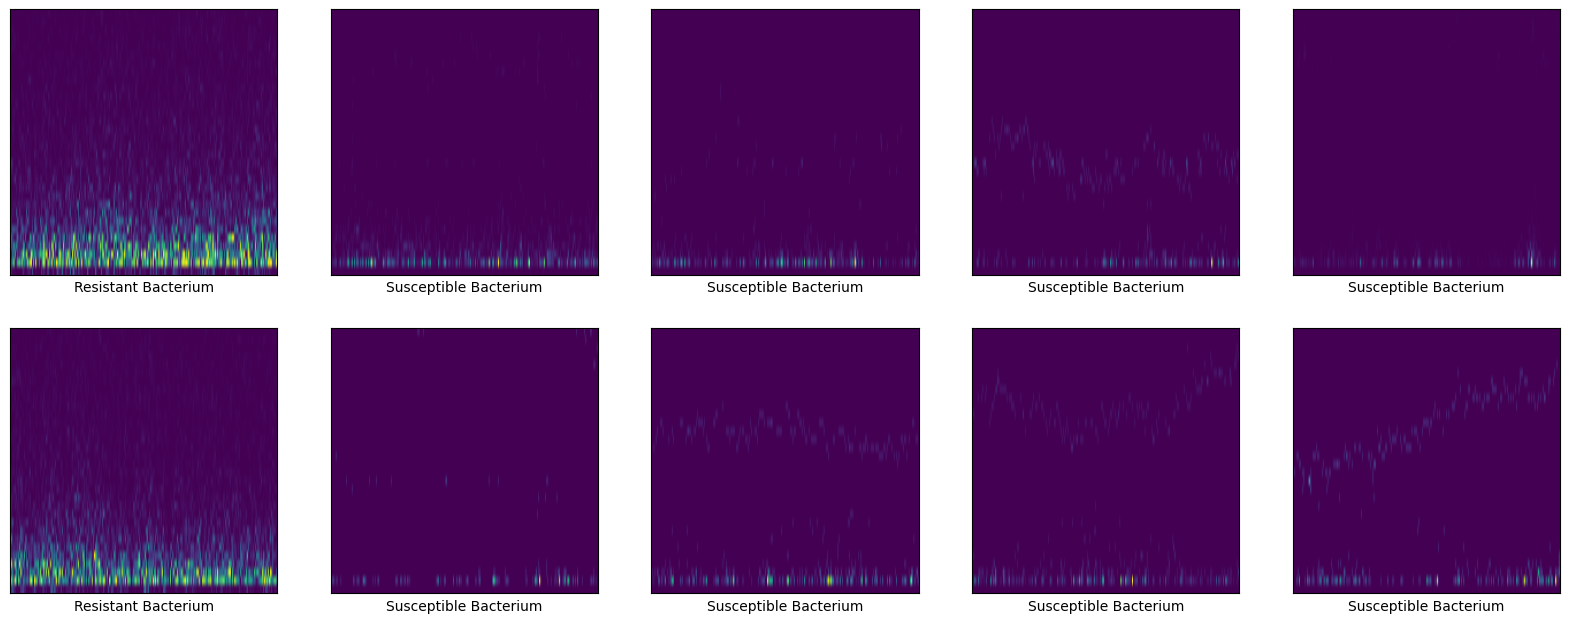

In [5]:
test_before_norm = get_some_img_in_arrays(test_images, test_labels, num_img = 10, 
                            class_names = ['Susceptible Bacterium', 'Resistant Bacterium'],
                            colorbar_active = False, 
                            vmin_val = None, vmax_val = None)

## Convolutional Neural Network Architecture

In [6]:
train_images = np.expand_dims(train_images, axis=-1)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models

model_CNN = models.Sequential()

model_CNN.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(train_images.shape[1], train_images.shape[2], train_images.shape[3])))
model_CNN.add(layers.MaxPooling2D((2, 2)))

model_CNN.add(layers.Conv2D(32, (3, 3), activation='relu'))
model_CNN.add(layers.MaxPooling2D((2, 2)))

model_CNN.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_CNN.add(layers.MaxPooling2D((2, 2)))

model_CNN.add(layers.Flatten())
model_CNN.add(layers.Dense(64, activation='relu'))
model_CNN.add(layers.Dense(2, activation='softmax'))

model_CNN.summary()

/Users/santiago/python-arm64-py311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-14 11:32:49.604921: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2025-11-14 11:32:49.604942: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-11-14 11:32:49.604945: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2025-11-14 11:32:49.605209: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-14 11:32:49.605216: I tensorflow/core/common_runtime/pluggable_device/pluggable_dev

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 231, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 115, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 113, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 56, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 54, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 27, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3456)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       221,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,442 (974.38 KB)

 Trainable params: 249,442 (974.38 KB)

 Non-trainable params: 0 (0.00 B)

### Compilation and training of the Neural Network

In [8]:
%%time
opt = keras.optimizers.Adam(learning_rate=0.0001)

model_CNN.compile(optimizer=opt, 
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
             metrics=['accuracy'])
number_epochs = 30
history = model_CNN.fit(train_images, train_labels, epochs=number_epochs,
                    validation_data=(test_images, test_labels))

Epoch 1/30


2025-11-14 11:32:50.026092: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8478 - loss: 0.6622 - val_accuracy: 0.8714 - val_loss: 0.6314
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9058 - loss: 0.6129 - val_accuracy: 0.9429 - val_loss: 0.5860
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9167 - loss: 0.5697 - val_accuracy: 0.9429 - val_loss: 0.5425
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9493 - loss: 0.5276 - val_accuracy: 0.9571 - val_loss: 0.4952
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9529 - loss: 0.4783 - val_accuracy: 0.9714 - val_loss: 0.4351
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9601 - loss: 0.4084 - val_accuracy: 0.9714 - val_loss: 0.3457
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9638 - loss: 0.3107 - val_accuracy: 0.9714 - val_loss: 0.2396
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9638 - loss: 0.2137 - val_accuracy: 0.9714 - val_loss: 0.1604
Epoch 9/30


 ## Confirming the accuracy of the Neural network
 
 ### Plot for Accuracy vs Val_accuracy

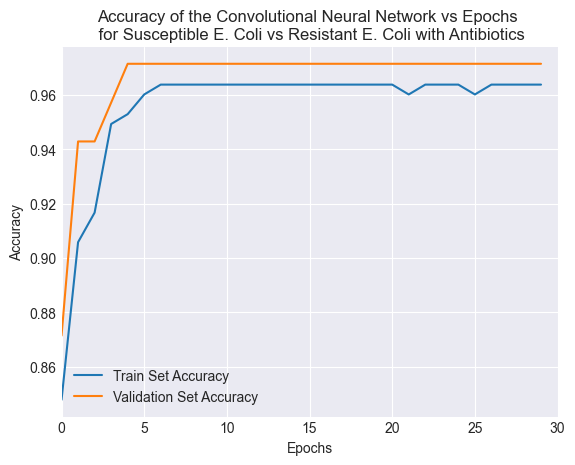

In [9]:
plot_accuracy_n_loss(model_history = history, epoch_num = number_epochs, 
        accuracy_plot = True, loss_plot = False, xlim = 'auto', ylim = 'auto', 
        title = 'Accuracy of the Convolutional Neural Network vs Epochs \n for Susceptible E. Coli vs Resistant E. Coli with Antibiotics',
        file_name = 'accuracy_plot_CNN_Pxx_ecoli_WA_susc_vs_ecoli_WA_resis_epochs_30_1',
        dpi_val = 300, save = False)

### Plotting the training validation loss:

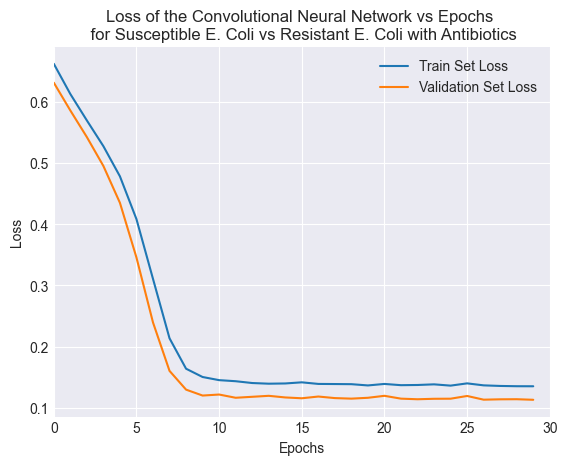

In [10]:
plot_accuracy_n_loss(model_history = history, epoch_num = number_epochs, 
        accuracy_plot = False, loss_plot = True, xlim = 'auto', ylim = 'auto', 
        title = 'Loss of the Convolutional Neural Network vs Epochs \n for Susceptible E. Coli vs Resistant E. Coli with Antibiotics',
        file_name = 'loss_plot_CNN_Pxx_ecoli_WA_susc_vs_ecoli_WA_resis_epochs_30_1',
        dpi_val = 300, save = False)

## Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Raw confusion matrix:
 [[49  0]
 [ 2 19]]


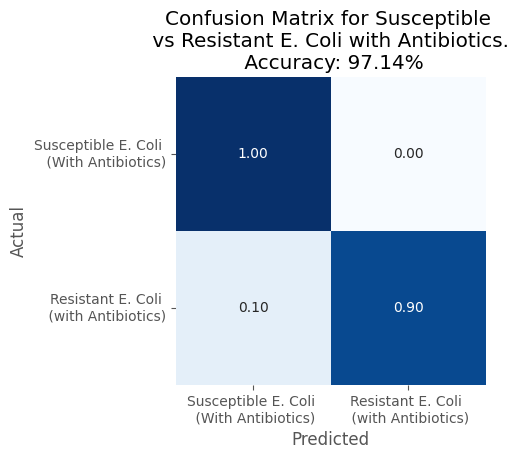

In [11]:
target_names = ['Susceptible E. Coli \n (With Antibiotics)', 'Resistant E. Coli \n (with Antibiotics)']

imgh, acc, _ = plot_conf_matrix(model_CNN, test_images, test_labels, algorithm_type = 'NN',
                        title = 'Confusion Matrix for Susceptible \n vs Resistant E. Coli with Antibiotics',
                        file_name = 'CNN_Pxx_ecoli_WA_susc_vs_ecoli_WA_resis_normalized_1', 
                        target_names = target_names, save = False, normalize = True)

### Save the model

In [12]:
from tensorflow.keras.models import load_model

model_CNN.save('CNN_Pxx_ecoli_susc_vs_ecoli_resis_epochs_30_acc_98_1.h5')  # creates a HDF5 file 'my_model.h5'
